# Tracking Political Change with Embeddings of Parliamentary Speeches
### 0. Imports & Paths
The following datasets were collected to analyse our research question
- Open Discourse Bundestag Dataset (covering 1949-2021)
- Chapel Expert Survey
- Manifesto Project

In [51]:
# Imports and Paths
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")

### 1. Load the raw data

In [52]:
speeches  = pd.read_csv(RAW / "speeches.csv")
ches      = pd.read_csv(RAW / "CHES.csv")
manifesto = pd.read_csv(RAW / "manifesto.csv")

# Auxiliary Open Discourse table
factions  = pd.read_csv(RAW / "factions.csv")

print("speeches: ", speeches.shape)
print("ches:     ", ches.shape)
print("manifesto:", manifesto.shape)
print("factions: ", factions.shape)

speeches:  (907644, 12)
ches:      (1441, 90)
manifesto: (5285, 175)
factions:  (28, 3)


/var/folders/s5/fy91nyld24n09t7z3kdvvvzh0000gn/T/ipykernel_37761/3045564478.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  manifesto = pd.read_csv(RAW / "manifesto.csv")


### 2. Preprocessing of speeches

*Possible decision*: Only look at speeches between 2010 and 2021 and filter out guest speakers

In [53]:
# Turn dates into real dates
speeches["date"] = pd.to_datetime(speeches["date"], errors="coerce")

# Keep only speeches from 2010 up to the end of the data (2021)
speeches = speeches[(speeches["date"] >= "2000-01-01") &
                    (speeches["date"] <= "2021-12-31")]

# Drop guests
speeches = speeches[speeches["positionShort"] != "Guest"]

print(f"After date + guest filter: {len(speeches)} speeches")

After date + guest filter: 299214 speeches


In [54]:
speeches.head()

,id,session,electoralTerm,firstName,lastName,politicianId,speechContent,factionId,documentUrl,positionShort,positionLong,date
595937,604683,80,14,Christoph,Matschie,11001434,Frau Präsidentin! Meine werten Kolleginnen und...,23,https://dip21.bundestag.de/dip21/btp/14/14080.pdf,Member of Parliament,NaN,2000-01-19
596004,604883,81,14,thomas,rachel,11002754,Sehr geehrter Herr\nPräsident! Liebe Kolleginn...,4,https://dip21.bundestag.de/dip21/btp/14/14081.pdf,Member of Parliament,NaN,2000-01-20
596116,604470,80,14,Rudolf,Seiters,11002156,Herr Kollege Irmer.\n\n,-1,https://dip21.bundestag.de/dip21/btp/14/14080.pdf,Presidium of Parliament,vizepräsident,2000-01-19
596127,604495,80,14,Rudolf,Seiters,11002156,Zusatzfrage. \n\n,-1,https://dip21.bundestag.de/dip21/btp/14/14080.pdf,Presidium of Parliament,vizepräsident,2000-01-19
596170,604885,81,14,peter,eckardt,11000431,Herr Präsident! Meine\nsehr verehrten Damen un...,23,https://dip21.bundestag.de/dip21/btp/14/14081.pdf,Member of Parliament,NaN,2000-01-20


In [55]:
# Ignore unmatched factions (-1) so chairing and minsterial speeches
speeches = speeches[speeches["factionId"] != -1]
print(f"{len(speeches):,} speeches remain after dropping factionId -1")

135,640 speeches remain after dropping factionId -1


In [56]:
speeches.head()

,id,session,electoralTerm,firstName,lastName,politicianId,speechContent,factionId,documentUrl,positionShort,positionLong,date
595937,604683,80,14,Christoph,Matschie,11001434,Frau Präsidentin! Meine werten Kolleginnen und...,23,https://dip21.bundestag.de/dip21/btp/14/14080.pdf,Member of Parliament,NaN,2000-01-19
596004,604883,81,14,thomas,rachel,11002754,Sehr geehrter Herr\nPräsident! Liebe Kolleginn...,4,https://dip21.bundestag.de/dip21/btp/14/14081.pdf,Member of Parliament,NaN,2000-01-20
596170,604885,81,14,peter,eckardt,11000431,Herr Präsident! Meine\nsehr verehrten Damen un...,23,https://dip21.bundestag.de/dip21/btp/14/14081.pdf,Member of Parliament,NaN,2000-01-20
596178,604905,81,14,jürgen,koppelin,11001180,Herr Präsident! Liebe\nKolleginnen und Kollege...,13,https://dip21.bundestag.de/dip21/btp/14/14081.pdf,Member of Parliament,NaN,2000-01-20
596515,605067,82,14,anita,schäfer,11003216,Sehr geehrter Herr Präsident! Verehrte Frau We...,4,https://dip21.bundestag.de/dip21/btp/14/14082.pdf,Member of Parliament,NaN,2000-01-21


In [57]:
# Tokenize with the Jina v3 multilingual tokenizer (XLM-R based, 8192 ctx)
# so the length distribution reflects the exact units the model will see.
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("jinaai/jina-embeddings-v3", trust_remote_code=True)
print(f"Tokenizer max length: {tok.model_max_length}")

texts = speeches["speechContent"].fillna("").tolist()

BATCH = 256
lengths = []
for i in range(0, len(texts), BATCH):
    enc = tok(texts[i:i + BATCH], add_special_tokens=True,
              truncation=False, padding=False)
    lengths.extend(len(x) for x in enc["input_ids"])
    if (i // BATCH) % 50 == 0:
        print(f"  {min(i + BATCH, len(texts)):>7,} / {len(texts):,} tokenized")

speeches["n_tokens"] = lengths

print(speeches["n_tokens"].describe(
    percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))

print("\nCount of speeches by small token-counts:")
print(speeches["n_tokens"].value_counts().sort_index().head(30))

Tokenizer max length: 8194
      256 / 135,640 tokenized


Token indices sequence length is longer than the specified maximum sequence length for this model (10090 > 8194). Running this sequence through the model will result in indexing errors


   13,056 / 135,640 tokenized
   25,856 / 135,640 tokenized
   38,656 / 135,640 tokenized
   51,456 / 135,640 tokenized
   64,256 / 135,640 tokenized
   77,056 / 135,640 tokenized
   89,856 / 135,640 tokenized
  102,656 / 135,640 tokenized
  115,456 / 135,640 tokenized
  128,256 / 135,640 tokenized
count    135640.000000
mean        744.663175
std         678.676460
min           2.000000
1%            4.000000
5%           12.000000
10%          36.000000
25%         120.000000
50%         705.000000
75%        1173.000000
90%        1590.000000
95%        1921.000000
99%        2662.000000
max       10090.000000
Name: n_tokens, dtype: float64

Count of speeches by small token-counts:
n_tokens
2       15
3        2
4     1805
5     1192
6     1097
7      571
8      469
9      569
10     537
11     498
12     381
13     332
14     332
15     318
16     323
17     289
18     298
19     301
20     260
21     272
22     242
23     285
24     249
25     261
26     269
27     270
28     242

In [58]:
# Bucket token counts into 100-token bins, count speeches in each
top = speeches["n_tokens"].max()
bins = range(0, top + 100, 100)
binned = pd.cut(speeches["n_tokens"], bins=bins, right=False)

counts = binned.value_counts().sort_index()
print(counts.head(25))   # covers 0-2500 tokens; the rest is a sparse tail

n_tokens
[0, 100)        29471
[100, 200)      16369
[200, 300)       7393
[300, 400)       3930
[400, 500)       2866
[500, 600)       3229
[600, 700)       4299
[700, 800)       5543
[800, 900)       6603
[900, 1000)      7767
[1000, 1100)     8459
[1100, 1200)     7796
[1200, 1300)     6582
[1300, 1400)     5066
[1400, 1500)     3850
[1500, 1600)     3097
[1600, 1700)     2455
[1700, 1800)     2045
[1800, 1900)     1723
[1900, 2000)     1377
[2000, 2100)     1153
[2100, 2200)      915
[2200, 2300)      732
[2300, 2400)      581
[2400, 2500)      443
Name: count, dtype: int64


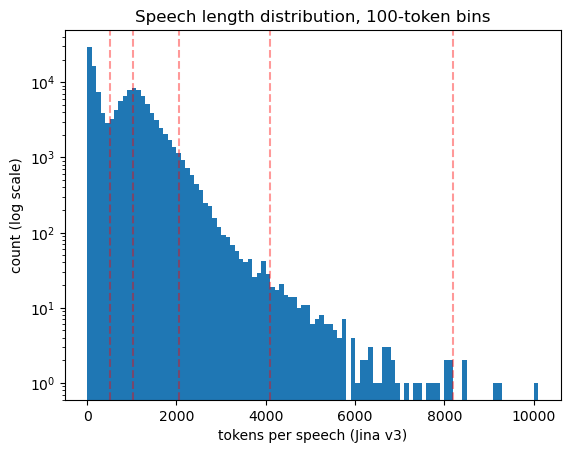

In [59]:
plt.hist(speeches["n_tokens"], bins=range(0, top + 100, 100))
plt.yscale("log")
plt.xlabel("tokens per speech (Jina v3)"); plt.ylabel("count (log scale)")
plt.title("Speech length distribution, 100-token bins")
# Mark common model context caps for reference
for cap in [512, 1024, 2048, 4096, 8192]:
    plt.axvline(cap, color="red", linestyle="--", alpha=0.4)
plt.show()

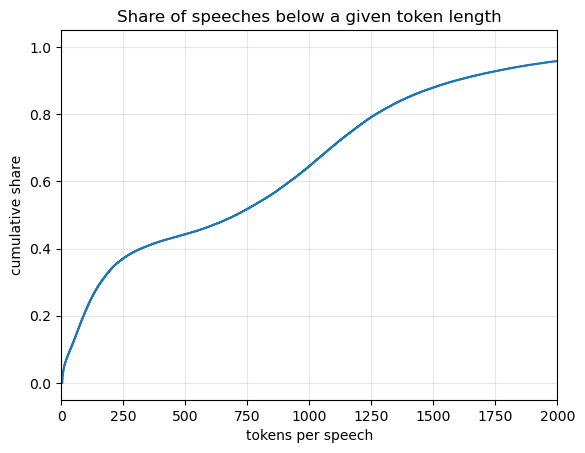

under   10 tokens:  4.2%
under   15 tokens:  5.8%
under   20 tokens:  6.9%
under   30 tokens:  8.8%
under   50 tokens: 12.4%
under  100 tokens: 21.7%
under  200 tokens: 33.8%
under  500 tokens: 44.3%


In [60]:
s = speeches["n_tokens"].sort_values()
cum = (s.rank(method="first") / len(s)).values

plt.plot(s.values, cum)
plt.xlim(0, 2000)
plt.xlabel("tokens per speech"); plt.ylabel("cumulative share")
plt.title("Share of speeches below a given token length")
plt.grid(True, alpha=.3)
plt.show()

# Exact shares at short-tail thresholds (for the min-length filter decision)
for t in [10, 15, 20, 30, 50, 100, 200, 500]:
    print(f"under {t:>4} tokens: {(speeches['n_tokens'] < t).mean():5.1%}")

In [61]:
speeches_under_15 = speeches[speeches["n_tokens"] < 30]
speeches_under_15["speechContent"].head(30)

598309                                  Ja, bitte sehr.\n\n
598807        Es ist mir eine Ehre,\nHerr Abgeordneter.\n\n
599951               Die habe ich noch nicht\nbekommen!\n\n
602543                                           Bitte.\n\n
603110                         Gerne, Frau Präsidentin.\n\n
604021                                Bitte, natürlich.\n\n
604634    Frau Staatssekretärin, bedeutet das, dass neue...
604693                                  Bitte.\n\n({0})\n\n
604735    Kann ich daraus\nschließen, dass der Bundeskan...
604738    Kann ich daraus\nschließen, dass der Standort ...
604745                                           Nein. \n\n
604802                                          Gerne. \n\n
604809                                         Sofort. \n\n
604813               Entschuldigung, Frau\nPräsidentin.\n\n
604830                                 Mache ich gerne.\n\n
604867                                 Wenn Sie meinen.\n\n
604869                      Das ist Ihre

In [62]:
short = speeches.loc[speeches["n_tokens"] < 100, ["n_tokens", "speechContent"]]
print(f"{len(short)} speeches under 15 tokens\n")

for i, (n, txt) in enumerate(short.head(50).itertuples(index=False), 1):
    print(f"[{i}] ({n} tokens) {txt!r}")
    print("-" * 80)

29471 speeches under 15 tokens

[1] (7 tokens) 'Ja, bitte sehr.\n\n'
--------------------------------------------------------------------------------
[2] (14 tokens) 'Es ist mir eine Ehre,\nHerr Abgeordneter.\n\n'
--------------------------------------------------------------------------------
[3] (9 tokens) 'Die habe ich noch nicht\nbekommen!\n\n'
--------------------------------------------------------------------------------
[4] (4 tokens) 'Bitte.\n\n'
--------------------------------------------------------------------------------
[5] (8 tokens) 'Gerne, Frau Präsidentin.\n\n'
--------------------------------------------------------------------------------
[6] (6 tokens) 'Bitte, natürlich.\n\n'
--------------------------------------------------------------------------------
[7] (73 tokens) 'Herr Staatssekretär,\nwelche Auswirkungen haben die restriktiven Rüstungsexportrichtlinien auf die deutsche Industrie? In welchem\nUmfang können davon Arbeitsplätze betroffen sein?\nWie bewertet 

In [63]:
# Exact truncation shares per model context cap (Jina v3 tokenizer, so
# numbers are accurate for Jina v3 / v2 and a close proxy for other XLM-R
# based encoders like multilingual-e5, gbert, xlm-r etc.).
for cap in [512, 1024, 2048, 4096, 8192]:
    over = speeches["n_tokens"] > cap
    lost_tokens = (speeches.loc[over, "n_tokens"] - cap).sum()
    total_tokens = speeches["n_tokens"].sum()
    print(f"{cap:>5} token cap: {over.mean():>5.1%} speeches truncated "
          f"({over.sum():>6,}), {lost_tokens / total_tokens:>5.1%} of all tokens dropped")

  512 token cap: 55.5% speeches truncated (75,215), 53.7% of all tokens dropped
 1024 token cap: 33.9% speeches truncated (46,023), 21.7% of all tokens dropped
 2048 token cap:  3.8% speeches truncated ( 5,123),  2.7% of all tokens dropped
 4096 token cap:  0.2% speeches truncated (   220),  0.2% of all tokens dropped
 8192 token cap:  0.0% speeches truncated (     5),  0.0% of all tokens dropped


*Possible decision*: Filter out very short speeches (e.g. under ~15 tokens) to drop interjections and procedural remarks.

*Note*: Truncation depends on the chosen model's context window. With the Jina v3 tokenizer, an 8192-token cap covers virtually all speeches; a 512-token cap would truncate the majority.

In [64]:
# Filter out short interjections or procedural remarks
min_tokens = 100
speeches = speeches[speeches["n_tokens"] >= min_tokens].copy()

print(f"After length filter: {len(speeches)} speeches")

After length filter: 106169 speeches


In [65]:
# Truncate any remaining speeches longer than the Jina v3 context (8192 tokens)
# so the stored text is guaranteed to fit the encoder end-to-end.
CAP = 8192
long_mask = speeches["n_tokens"] > CAP
print(f"Truncating {long_mask.sum()} speeches (> {CAP} tokens) to {CAP} tokens")

def _truncate_to_cap(text):
    ids = tok.encode(text, add_special_tokens=False,
                     truncation=True, max_length=CAP)
    return tok.decode(ids, skip_special_tokens=True)

speeches.loc[long_mask, "speechContent"] = (
    speeches.loc[long_mask, "speechContent"].apply(_truncate_to_cap)
)

# Recompute n_tokens for the ones we just shortened
if long_mask.any():
    new_ids = tok(speeches.loc[long_mask, "speechContent"].tolist(),
                  add_special_tokens=True, truncation=False,
                  padding=False)["input_ids"]
    speeches.loc[long_mask, "n_tokens"] = [len(x) for x in new_ids]

print(f"Max tokens after truncation: {speeches['n_tokens'].max()}")

Truncating 5 speeches (> 8192 tokens) to 8192 tokens
Max tokens after truncation: 8194


*Possible decision*: Keep politician IDs as they are and use the factions IDs in the speeches dataset and factions dataset to match and create a new column with faction names

In [66]:
# factions.csv columns: id, abbreviation, full_name
# Rename so the key lines up with the speeches table
faction_names = factions.rename(columns={"id": "factionId", "abbreviation": "party"})

# Merge to attach the party name; factionId stays, `party` is the new column
speeches = speeches.merge(faction_names[["factionId", "party"]],
                          on="factionId", how="left")

print(speeches["party"].value_counts())

party
CDU/CSU         31350
SPD             23587
Grüne           18652
DIE LINKE.      13593
FDP             13438
AfD              3529
PDS              1398
Fraktionslos      622
Name: count, dtype: int64


In [67]:
# An MP whose factionId changes over time has switched factions
faction_per_mp = speeches.groupby("politicianId")["factionId"].nunique()
switchers = faction_per_mp[faction_per_mp > 1].index

print(f"{len(switchers)} MPs appear under more than one faction (possible switchers)")

21 MPs appear under more than one faction (possible switchers)


**Unit of Analysis: MP-year**

*Possible decision*: MP-year is the primary unit because single speeches are too noisy (dominated by the day's topic), MP-month is sparse as most MPs dont speak enough per month and MP-year gives enought text per cell for a stable average.

In [68]:
speeches["year"] = speeches["date"].dt.year
speeches["year_month"] = speeches["date"].dt.to_period("M").astype(str)

# How much text lands in each cell under each option?
per_mp_year  = speeches.groupby(["politicianId", "year"]).size()
per_mp_month = speeches.groupby(["politicianId", "year_month"]).size()

print(f"Median speeches per MP-year : {per_mp_year.median():.0f}")
print(f"Median speeches per MP-month: {per_mp_month.median():.0f}")
print(f"MP-months with fewer than 3 speeches: {(per_mp_month < 3).mean():.0%}")

Median speeches per MP-year : 6
Median speeches per MP-month: 1
MP-months with fewer than 3 speeches: 77%


In [69]:
# Define the events
events = pd.DataFrame([
    # External shocks / crises
    ("2001-09-11", "9/11 terror attacks",                                  "crisis"),
    ("2008-09-15", "Lehman Brothers collapse / global financial crisis",   "crisis"),
    ("2011-03-11", "Fukushima nuclear disaster",                           "crisis"),
    ("2016-01-01", "Shift to migration scepticism in Germany (post-Cologne NYE)", "crisis"),
    ("2016-06-23", "Brexit referendum",                                    "crisis"),
    ("2016-11-08", "Donald Trump elected US president",                    "election"),
    ("2020-03-22", "COVID-19 pandemic (first German lockdown)",            "crisis"),

    # German federal elections (Bundestagswahlen) in the 2000-2021 window
    ("2002-09-22", "Federal election - Schröder II (SPD/Grüne)",           "election"),
    ("2005-09-18", "Federal election - Merkel I (CDU-CSU/SPD, grand coalition)", "election"),
    ("2009-09-27", "Federal election - Merkel II (CDU-CSU/FDP)",           "election"),
    ("2013-09-22", "Federal election - Merkel III (CDU-CSU/SPD)",          "election"),
    ("2017-09-24", "Federal election - Merkel IV, AfD enters Bundestag",   "election"),
    ("2021-09-26", "Federal election - Scholz (SPD/Grüne/FDP, Ampel)",     "election"),
], columns=["date", "label", "type"])

events["date"] = pd.to_datetime(events["date"])
events = events.sort_values("date").reset_index(drop=True)
events

,date,label,type
0,2001-09-11,9/11 terror attacks,crisis
1,2002-09-22,Federal election - Schröder II (SPD/Grüne),election
2,2005-09-18,"Federal election - Merkel I (CDU-CSU/SPD, gran...",election
3,2008-09-15,Lehman Brothers collapse / global financial cr...,crisis
4,2009-09-27,Federal election - Merkel II (CDU-CSU/FDP),election
5,2011-03-11,Fukushima nuclear disaster,crisis
6,2013-09-22,Federal election - Merkel III (CDU-CSU/SPD),election
7,2016-01-01,Shift to migration scepticism in Germany (post...,crisis
8,2016-06-23,Brexit referendum,crisis
9,2016-11-08,Donald Trump elected US president,election


### 3. Preliminary Analysis of Speeches

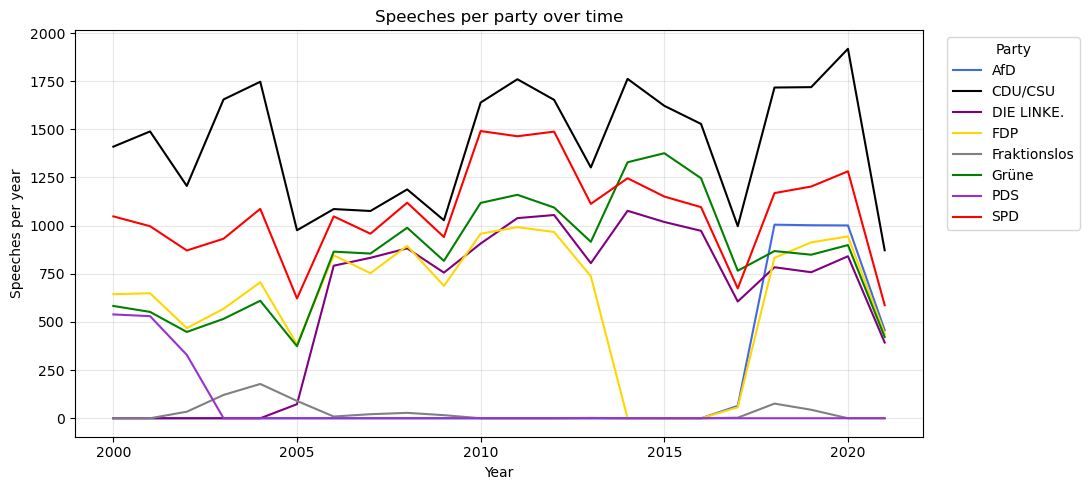

In [70]:
# Speeches per party over time
party_colors = {
    "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
    "FDP": "gold", "DIE LINKE.": "purple", "AfD": "royalblue",
    "PDS": "darkorchid", "Fraktionslos": "grey",
}

per_year_party = (speeches.groupby(["year", "party"]).size()
                  .unstack("party").fillna(0))

ax = per_year_party.plot(
    figsize=(11, 5),
    color=[party_colors.get(c) for c in per_year_party.columns],
)
ax.set_ylabel("Speeches per year")
ax.set_xlabel("Year")
ax.set_title("Speeches per party over time")
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

/var/folders/s5/fy91nyld24n09t7z3kdvvvzh0000gn/T/ipykernel_37761/2330488043.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


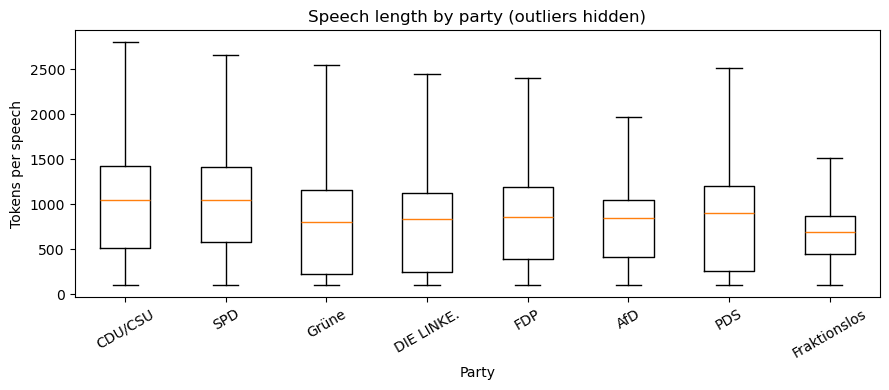

                count    mean     50%     max
party                                        
AfD            3529.0   781.0   843.0  2577.0
CDU/CSU       31350.0  1055.6  1047.0  8194.0
DIE LINKE.    13593.0   804.3   831.0  7141.0
FDP           13438.0   870.1   857.0  5751.0
Fraktionslos    622.0   656.5   691.0  2050.0
Grüne         18652.0   792.0   797.0  6876.0
PDS            1398.0   876.1   898.0  4962.0
SPD           23587.0  1053.3  1048.0  8194.0


In [71]:
# Speech length distribution by party (Jina v3 tokens)
order = speeches["party"].value_counts().index.tolist()
data = [speeches.loc[speeches["party"] == p, "n_tokens"].values for p in order]

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(data, labels=order, showfliers=False)
ax.set_ylabel("Tokens per speech")
ax.set_xlabel("Party")
ax.set_title("Speech length by party (outliers hidden)")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

print(speeches.groupby("party")["n_tokens"]
      .describe()[["count", "mean", "50%", "max"]].round(1))

In [72]:
# Vocabulary per party: total word tokens vs. unique word types.
# NB: type-token ratio shrinks with corpus size, so read TTR with care —
# it is a rough indicator, not a fair richness measure across parties.
import re
_word = re.compile(r"[A-Za-zÄÖÜäöüß]+")

rows = []
for party, group in speeches.groupby("party"):
    total = 0
    types = set()
    for text in group["speechContent"]:
        words = [w.lower() for w in _word.findall(text)]
        total += len(words)
        types.update(words)
    rows.append({"party": party, "tokens": total, "types": len(types)})

vocab = (pd.DataFrame(rows).set_index("party")
         .sort_values("tokens", ascending=False))
vocab["type_token_ratio"] = vocab["types"] / vocab["tokens"]
print(vocab)

                tokens   types  type_token_ratio
party                                           
CDU/CSU       20649799  272939          0.013218
SPD           15567726  231782          0.014889
Grüne          9172227  182832          0.019933
FDP            7258033  153650          0.021170
DIE LINKE.     6674033  153800          0.023045
AfD            1643192   79965          0.048664
PDS             754597   46126          0.061127
Fraktionslos    252960   24060          0.095114


In [73]:
# Missing data
missing = speeches.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "  (none)")

empty_text = (speeches["speechContent"].fillna("").str.strip() == "").sum()
print(f"\nTotal speeches: {len(speeches):,}")
print(f"Rows with empty speechContent: {empty_text}")

Columns with missing values:
positionLong    106169
firstName           10
lastName             3
dtype: int64

Total speeches: 106,169
Rows with empty speechContent: 0


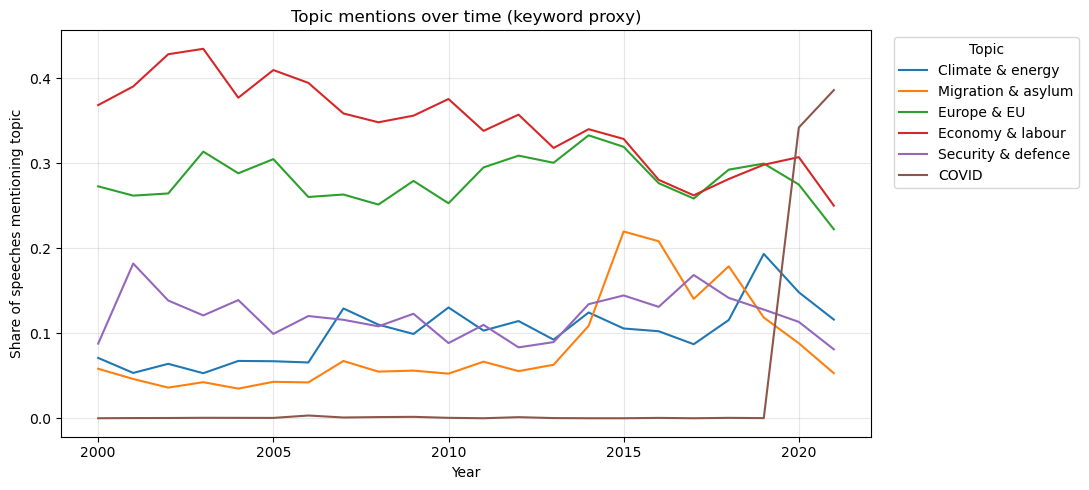

In [74]:
# Simple keyword-based topic frequency over time.
# NOTE: this is a first-pass proxy, not a topic model. Stems are chosen so
# common German compounds match (e.g. 'klima' also catches 'Klimaschutz').
import re

topics = {
    "Climate & energy":   ["klima", "energiewende", "erneuerbar"],
    "Migration & asylum": ["migration", "migrant", "flüchtling", "flucht", "asyl"],
    "Europe & EU":        ["europ", "brüssel"],
    "Economy & labour":   ["wirtschaft", "arbeitsmarkt", "arbeitslos", "inflation"],
    "Security & defence": ["bundeswehr", "verteidigung", "terror", "nato"],
    "COVID":              ["corona", "pandemie", "covid", "lockdown"],
}

lower = speeches["speechContent"].str.lower()
topic_flags = pd.DataFrame({
    name: lower.str.contains(r"\b(?:" + "|".join(kws) + r")", regex=True, na=False)
    for name, kws in topics.items()
})
topic_flags["year"] = speeches["year"].values

share_by_year = topic_flags.groupby("year").mean()

ax = share_by_year.plot(figsize=(11, 5))
ax.set_ylabel("Share of speeches mentioning topic")
ax.set_xlabel("Year")
ax.set_title("Topic mentions over time (keyword proxy)")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

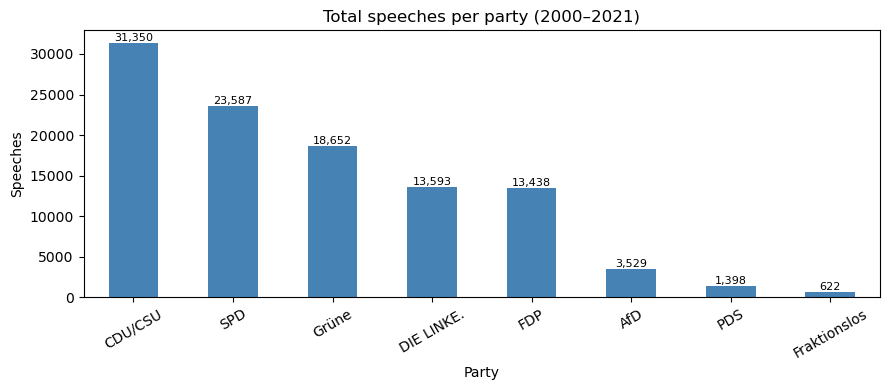

In [75]:
# Total speeches per party across the whole window
party_counts = speeches["party"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
party_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Speeches"); ax.set_xlabel("Party")
ax.set_title(f"Total speeches per party "
             f"({int(speeches['year'].min())}–{int(speeches['year'].max())})")
for i, v in enumerate(party_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

### Peek at CHES

In [16]:
# Peek at CHES
print(list(ches.columns))
ches.head()

['year', 'country', 'eastwest', 'eumember', 'party_id', 'party', 'cmp_id', 'vote', 'seat', 'electionyear', 'epvote', 'family', 'govt', 'lrgen', 'lrecon', 'lrecon_salience', 'lrecon_dissent', 'lrecon_blur', 'galtan', 'galtan_salience', 'galtan_dissent', 'galtan_blur', 'eu_position', 'eu_salience', 'eu_dissent', 'eu_blur', 'spendvtax', 'spendvtax_salience', 'deregulation', 'dereg_salience', 'redistribution', 'redist_salience', 'econ_interven', 'civlib_laworder', 'civlib_salience', 'sociallifestyle', 'social_salience', 'womens_rights', 'lgbtq_rights', 'samesex_marriage', 'religious_principles', 'relig_salience', 'immigrate_policy', 'immigrate_salience', 'immigrate_dissent', 'multiculturalism', 'multicult_salience', 'multicult_dissent', 'nationalism', 'nationalism_salience', 'ethnic_minorities', 'ethnic_salience', 'urban_rural', 'urban_salience', 'environment', 'enviro_salience', 'climate_change', 'climate_change_salience', 'protectionism', 'regions', 'region_salience', 'international_secu

,year,country,eastwest,eumember,party_id,party,cmp_id,vote,seat,electionyear,...,people_vs_elite,antielite_salience,corrupt_salience,members_vs_leadership,executive_power,judicial_independence,mip_one,mip_two,mip_three,chesversion
0,1999,1,1,1,104,ECOLO,21111.0,7.3,7.3,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
1,1999,1,1,1,112,VB,21914.0,9.9,10.0,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
2,1999,1,1,1,111,FDF,21912.0,2.4,3.0,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
3,1999,1,1,1,110,VU,21913.0,5.6,5.3,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
4,1999,1,1,1,105,AGALEV,21112.0,7.0,6.0,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1


In [17]:
# Filter CHES to Germany
ches_de = ches[ches["country"] == 3].copy()

print(f"CHES Germany rows: {len(ches_de)}")
print("Years available:", sorted(ches_de["year"].unique()))
print()

# The columns we care about: party identity + the cmp_id bridge + ideology scores
cols = ["year", "party_id", "party", "cmp_id", "lrgen", "lrecon", "galtan"]
cols = [c for c in cols if c in ches_de.columns]
ches_de[cols].sort_values(["party", "year"])

CHES Germany rows: 54
Years available: [np.int64(1999), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2019), np.int64(2024)]



,year,party_id,party,cmp_id,lrgen,lrecon,galtan
183,2014,310,AfD,41953.0,8.923077,8.333333,8.692307
189,2019,310,AfD,41953.0,9.238095,7.000000,9.523809
204,2024,310,AfD,41953.0,9.263158,7.631579,9.388889
199,2024,313,BSW,NaN,3.625000,2.777778,7.062500
151,1999,301,CDU,41521.0,5.866667,5.666667,6.333333
161,2002,301,CDU,41521.0,5.930000,5.860000,6.640000
165,2006,301,CDU,41521.0,6.360000,6.820000,6.910000
175,2010,301,CDU,41521.0,6.125000,6.000000,6.250000
182,2014,301,CDU,41521.0,5.923077,5.916667,6.000000
191,2019,301,CDU,41521.0,5.857143,5.904762,5.857143


### Peek at Manifesto

In [18]:
print(list(manifesto.columns)[:30])
manifesto.head()

['country', 'countryname', 'oecdmember', 'eumember', 'edate', 'date', 'party', 'partyname', 'partyabbrev', 'parfam', 'candidatename', 'coderid', 'manual', 'coderyear', 'testresult', 'testeditsim', 'pervote', 'voteest', 'presvote', 'absseat', 'totseats', 'progtype', 'datasetorigin', 'corpusversion', 'total', 'peruncod', 'per101', 'per102', 'per103', 'per104']


,country,countryname,oecdmember,eumember,edate,date,party,partyname,partyabbrev,parfam,...,per608_3,per703_1,per703_2,rile,planeco,markeco,welfare,intpeace,datasetversion,id_perm
0,11,Sweden,0,0,17/09/1944,194409,11220,Communist Party of Sweden,SKP,20,...,NaN,NaN,NaN,9.60,1.9,1.900,0.0,1.900,2025a,JN1LZH
1,11,Sweden,0,0,17/09/1944,194409,11320,Social Democratic Labour Party,SAP,30,...,NaN,NaN,NaN,-37.80,3.3,2.200,33.4,5.600,2025a,CMR7F6
2,11,Sweden,0,0,17/09/1944,194409,11420,People’s Party,FP,40,...,NaN,NaN,NaN,9.50,3.2,6.400,14.3,1.600,2025a,Z6OL6C
3,11,Sweden,0,0,17/09/1944,194409,11620,Right Party,NaN,60,...,NaN,NaN,NaN,28.00,1.8,22.800,10.6,0.000,2025a,YMKVN2
4,11,Sweden,0,0,17/09/1944,194409,11810,Agrarian Party,NaN,80,...,NaN,NaN,NaN,23.81,0.0,19.048,0.0,4.762,2025a,U4SCRD


In [19]:
# Two ways to isolate Germany — use whichever column you have
if "country" in manifesto.columns:
    mani_de = manifesto[manifesto["country"] == 41].copy()
else:
    mani_de = manifesto[manifesto["countryname"] == "Germany"].copy()

print(f"Manifesto Germany rows: {len(mani_de)}")

cols = ["party", "partyname", "date", "edate", "rile"]
cols = [c for c in cols if c in mani_de.columns]
mani_de[cols].sort_values("date").tail(20)

Manifesto Germany rows: 104


,party,partyname,date,edate,rile
2064,41223,The Left,201709,24/09/2017,-41.914
2065,41320,Social Democratic Party of Germany,201709,24/09/2017,-21.453
2066,41420,Free Democratic Party,201709,24/09/2017,0.578
2067,41521,Christian Democratic Union/Christian Social Union,201709,24/09/2017,2.757
2068,41953,Alternative for Germany,201709,24/09/2017,17.430
2075,41953,Alternative for Germany,202109,26/09/2021,26.048
2074,41912,South Schleswig Voters’ Union,202109,26/09/2021,-22.450
2073,41521,Christian Democratic Union/Christian Social Union,202109,26/09/2021,3.495
2071,41320,Social Democratic Party of Germany,202109,26/09/2021,-24.673
2070,41223,The Left,202109,26/09/2021,-36.167


In [76]:
# Save the preprocessed dataset
cols = ["id", "speechContent", "politicianId", "firstName", "lastName", "positionShort", "factionId",
        "party", "date", "year", "year_month", "n_tokens"]
cols = [c for c in cols if c in speeches.columns]

speeches[cols].to_csv(PROCESSED / "speeches_preprocessed.csv.zip",
                      index=False, compression="zip")